# Credit Risk Analysis - Data Cleaning & EDA

This notebook performs data cleaning, preprocessing, and exploratory data analysis to understand patterns affecting loan defaults.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print("Libraries imported successfully")

Libraries imported successfully


In [3]:
df = pd.read_csv("../data/loan_sample.csv")
df.shape

(200000, 145)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 145 entries, id to settlement_term
dtypes: float64(106), int64(4), object(35)
memory usage: 221.3+ MB


In [5]:
drop_cols = [
    'id', 'member_id', 'url', 'desc', 'title'
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(20)

next_pymnt_d                                  200000
orig_projected_additional_accrued_interest    199084
sec_app_mths_since_last_major_derog           198923
hardship_dpd                                  198379
hardship_payoff_balance_amount                198379
deferral_term                                 198379
hardship_reason                               198379
hardship_type                                 198379
hardship_last_payment_amount                  198379
hardship_loan_status                          198379
hardship_length                               198379
payment_plan_start_date                       198379
hardship_end_date                             198379
hardship_start_date                           198379
hardship_amount                               198379
hardship_status                               198379
sec_app_revol_util                            197294
sec_app_inq_last_6mths                        197231
sec_app_mort_acc                              

In [7]:
df = df.dropna(thresh=len(df)*0.5, axis=1)

In [8]:
df.fillna({
    'emp_length': 'Unknown'
}, inplace=True)

In [9]:
df['loan_status'].value_counts()

loan_status
Charged Off    100000
Fully Paid     100000
Name: count, dtype: int64

In [10]:
df['loan_status'] = df['loan_status'].apply(
    lambda x: 1 if x == 'Charged Off' else 0
)

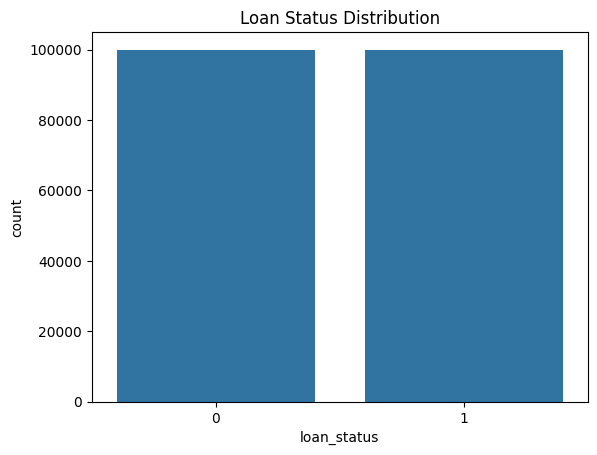

In [11]:
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

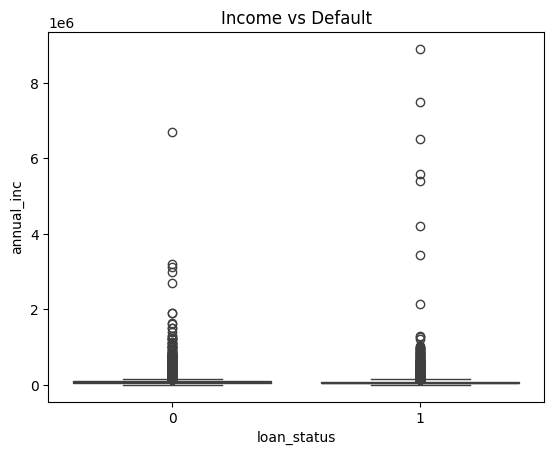

In [12]:
sns.boxplot(x='loan_status', y='annual_inc', data=df)
plt.title("Income vs Default")
plt.show()

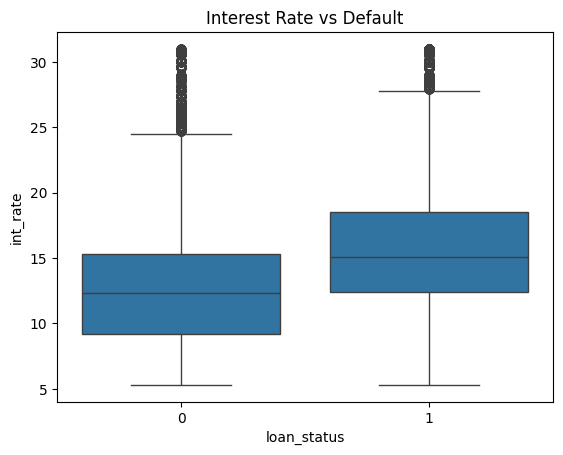

In [14]:
sns.boxplot(x='loan_status', y='int_rate', data=df)
plt.title("Interest Rate vs Default")
plt.show()

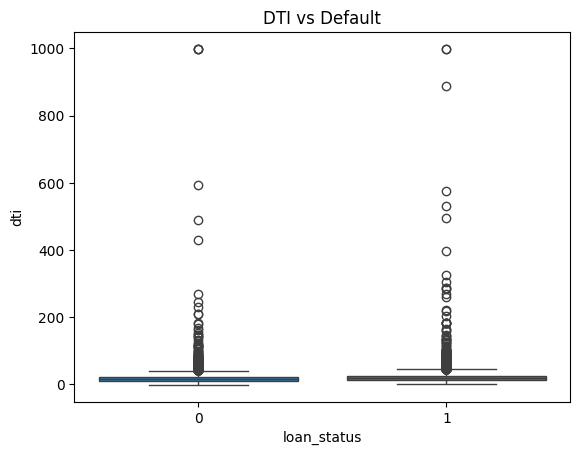

In [15]:
sns.boxplot(x='loan_status', y='dti', data=df)
plt.title("DTI vs Default")
plt.show()

In [16]:
df.groupby('purpose')['loan_status'].mean().sort_values(ascending=False).head(10)

purpose
small_business        0.626237
renewable_energy      0.620253
moving                0.555482
medical               0.518737
debt_consolidation    0.518083
other                 0.512263
house                 0.500000
vacation              0.484872
major_purchase        0.481180
home_improvement      0.478077
Name: loan_status, dtype: float64

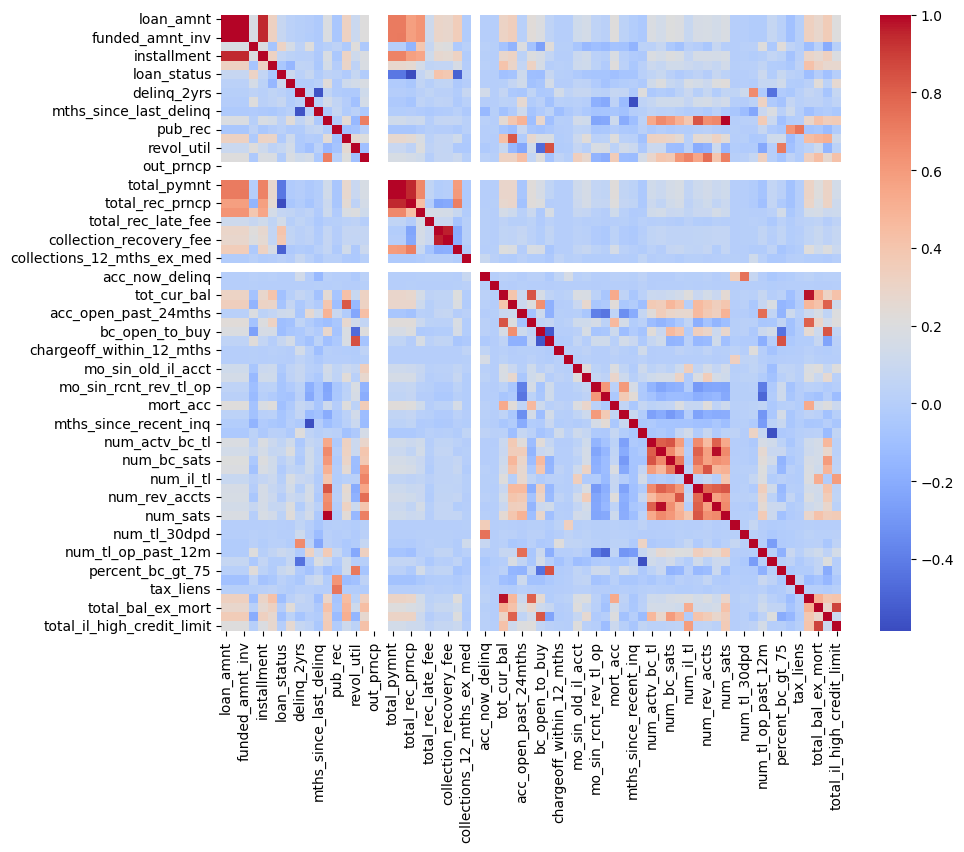

In [18]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.show()

## Key Insights

- Borrowers with high DTI are more likely to default
- Lower FICO scores strongly correlate with higher risk
- Certain loan purposes show higher default rates
- Income plays a role but is not the strongest predictor